# (27) poisson + BALLS64: (32, 128.0)

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
npix = 64
cfg_vae, cfg_tr = default_configs(model_type, f'BALLS{npix}')

cfg_vae['n_latents'] = int(npix * 2.0)

cfg_vae['t_train'] = 32
cfg_vae['beta_outer'] = 128.0 + 32

cfg_vae['clamp_u'] = 5.0
cfg_vae['clamp_du'] = 5.0

cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  528.6 K   |
|     ———     |    ———     |
|    layer    |  528.6 K   |
+-------------+------------+

poisson_BALLS64_t-32_b-160_k-[128]_u-5,du-5
b200-ep600-lr(0.0005)_temp(0.01:0.5)_gr(5000)_(2025_04_27,13:45)

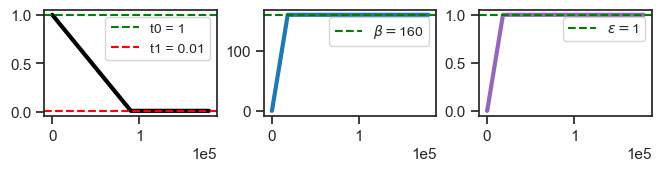

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
tr.print()
tr.show_schedules()

In [5]:
tr.n_iters

180000

In [6]:
print(tr.model.layer)
print(tr.model.layer.n_exp)

PoissonLayer(input_dim=4096, latent_dim=128, temperature=1, beta_inner=1, eps=1)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>),)

In [8]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 600, avg loss: -439.381: 100%|██████| 600/600 [4:02:19<00:00, 24.23s/it]


In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0054], device='cuda:1', grad_fn=<ExpBackward0>),)

In [10]:
print(tr.model.layer.n_exp)

tensor([62, 76, 69, 65, 61, 57, 54, 51, 49, 47, 46, 46, 46, 46, 46, 46, 46, 46,
        47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 48, 47, 48],
       device='cuda:1', dtype=torch.int32)

In [11]:
list(tr.model.stats)

['u_min', 'u_max', 'du_min', 'du_max']

In [12]:
u_max = np.array(tr.model.stats['u_max']).squeeze()
du_max = np.array(tr.model.stats['du_max']).squeeze()

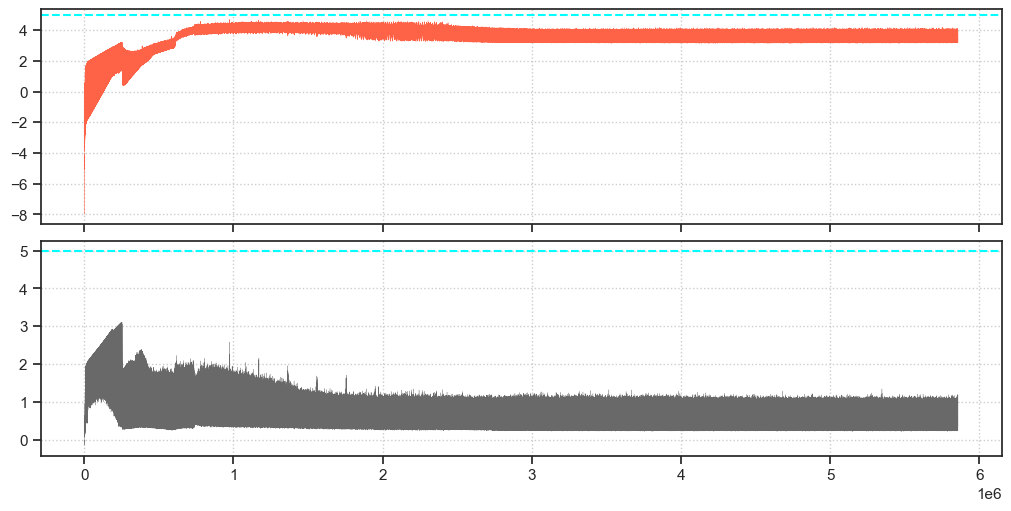

In [16]:
fig, axes = create_figure(2, 1, (10, 5), sharex='all')
axes[0].plot(u_max, lw=0.2, label='u_max', color='tomato')
axes[1].plot(du_max, lw=0.2, label='du_max', color='dimgrey')
axes[0].axhline(tr.model.cfg.clamp_u, color='cyan', ls='--')
axes[1].axhline(tr.model.cfg.clamp_du, color='cyan', ls='--')
add_grid(axes)
plt.show()

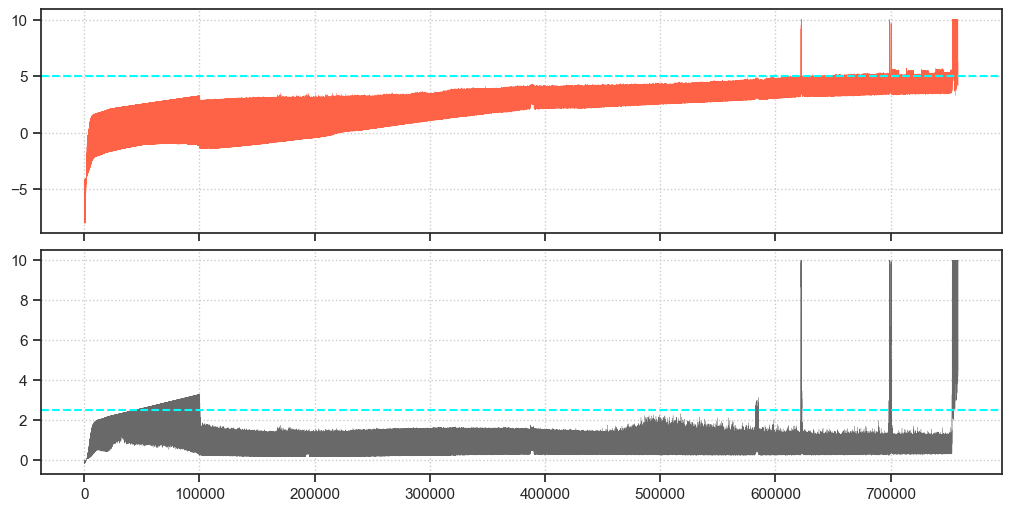

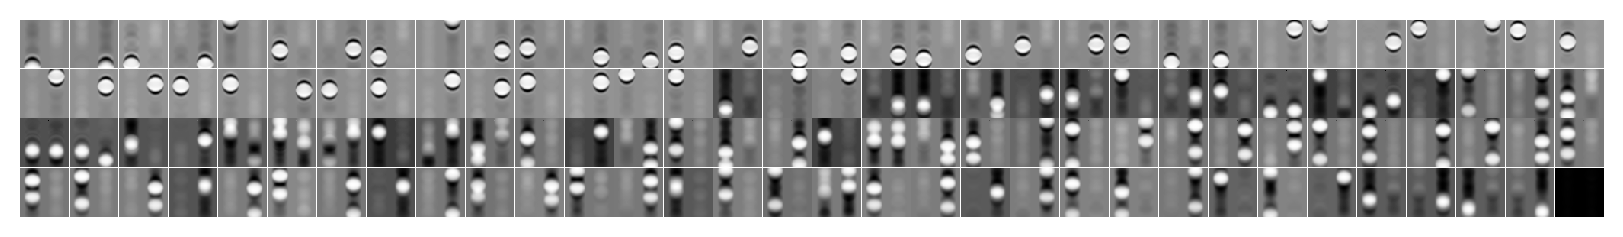

In [17]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=4);

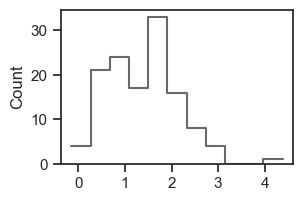

In [18]:
histplot(u0, color='dimgrey')
plt.show()

In [23]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())
(bias > 10).sum()

12

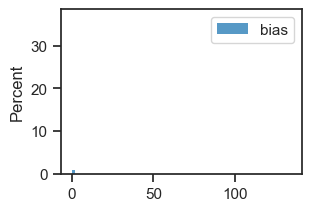

In [21]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

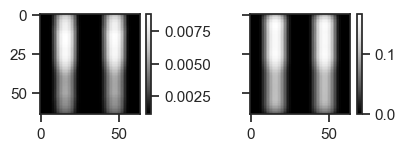

In [24]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(npix, npix)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.17s/it]


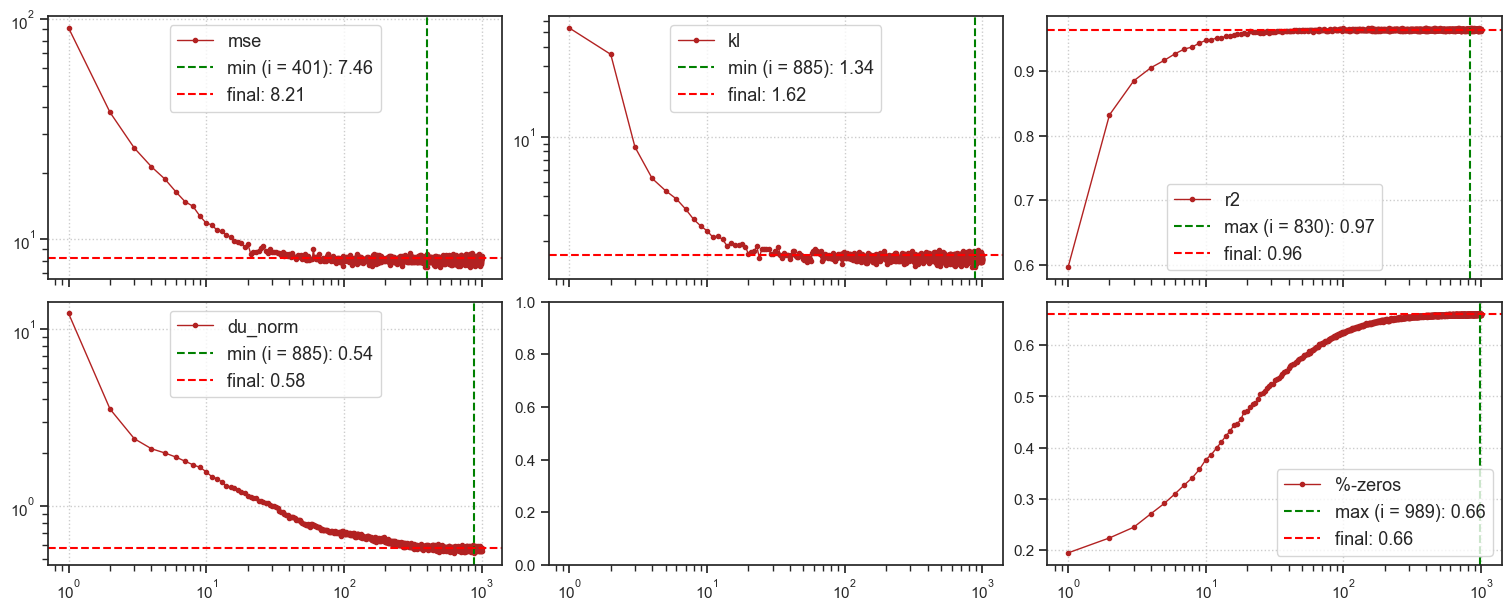

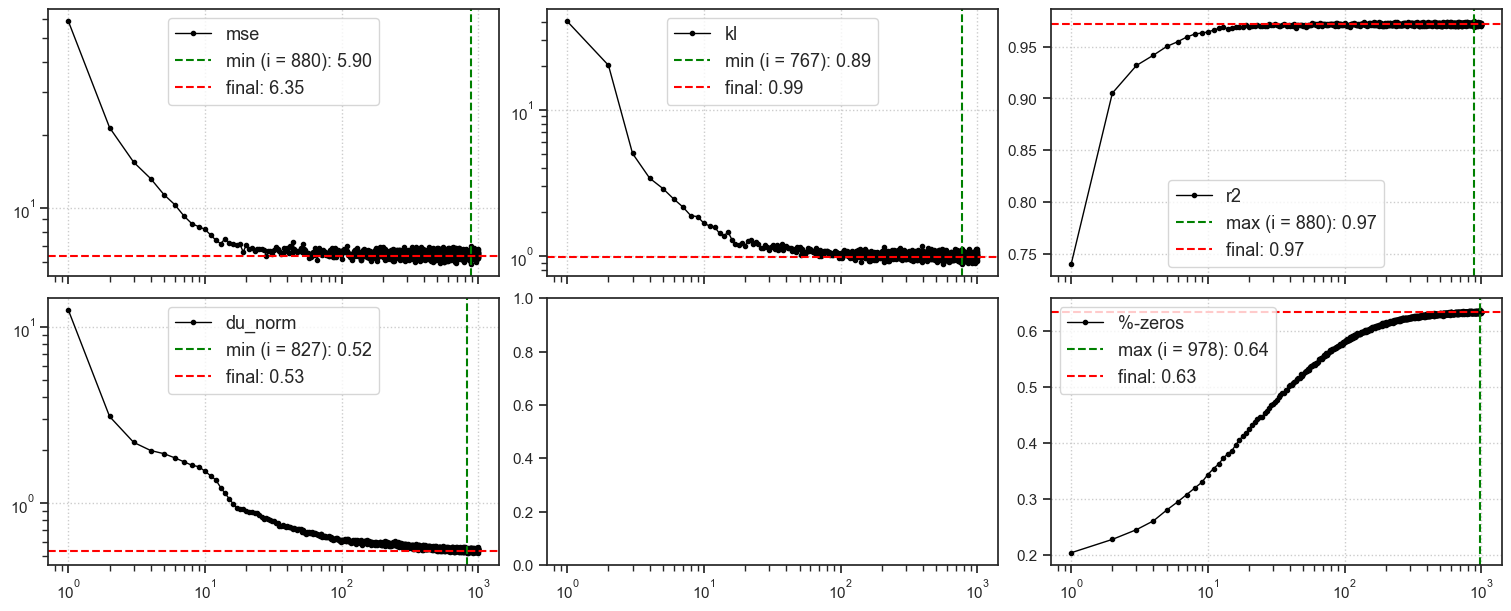

CPU times: user 11.8 s, sys: 112 ms, total: 12 s
Wall time: 12 s


In [27]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=2,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['vld', 'tst']
}
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')

In [30]:
from analysis.linear import untangle_score

output = untangle_score(tr, t_total=1000, save_freq=50)

100%|█████████████████████████████████| 25/25 [01:44<00:00,  4.19s/it]


In [31]:
print(f"r2 tst:", output['r2_zg']['tst'])

r2 tst:
{
    1: array([0.77642524, 0.6857696 ], dtype=float32),
    50: array([0.95009774, 0.9295767 ], dtype=float32),
    100: array([0.9479507, 0.8844201], dtype=float32),
    150: array([0.950443  , 0.85446745], dtype=float32),
    200: array([0.95197594, 0.85926765], dtype=float32),
    250: array([0.94582564, 0.8709789 ], dtype=float32),
    300: array([0.942435 , 0.8665987], dtype=float32),
    350: array([0.95101035, 0.87075347], dtype=float32),
    400: array([0.951228  , 0.87564486], dtype=float32),
    450: array([0.95318544, 0.87063324], dtype=float32),
    500: array([0.9479624, 0.8719212], dtype=float32),
    550: array([0.95239705, 0.8791559 ], dtype=float32),
    600: array([0.94898677, 0.882508  ], dtype=float32),
    650: array([0.9458588, 0.8759938], dtype=float32),
    700: array([0.9500876 , 0.88325274], dtype=float32),
    750: array([0.95138824, 0.8811962 ], dtype=float32),
    800: array([0.9527305, 0.8786564], dtype=float32),
    850: array([0.95064455, 0.87513727], dtype=float32),
    900: array([0.9540756, 0.8681136], dtype=float32),
    950: array([0.94506717, 0.8763307 ], dtype=float32),
    1000: array([0.9488919, 0.8745679], dtype=float32)
}

r2 tst:
{
    1: array([-1.6319821 ,  0.72672826], dtype=float32),
    100: array([0.9737534, 0.9901319], dtype=float32),
    200: array([0.98411494, 0.9894894 ], dtype=float32),
    300: array([0.98571974, 0.98771966], dtype=float32),
    400: array([0.98594934, 0.9876326 ], dtype=float32),
    500: array([0.98411584, 0.9878618 ], dtype=float32),
    600: array([0.9840913 , 0.98761535], dtype=float32),
    700: array([0.98281133, 0.9870516 ], dtype=float32),
    800: array([0.98209316, 0.9878183 ], dtype=float32),
    900: array([0.9832502, 0.9880444], dtype=float32),
    1000: array([0.984105 , 0.9883092], dtype=float32)
}